Libraries loaded successfully!
✓ Loaded ethiopia_clean.csv - 4108 rows
✓ Loaded kenya_clean.csv - 4108 rows
✓ Loaded sudan_clean.csv - 4108 rows
✓ Loaded tanzania_clean.csv - 4108 rows
✓ Loaded nigeria_clean.csv - 4108 rows

Total combined data: 20540 rows
Countries: <ArrowStringArray>
['Ethiopia', 'Kenya', 'Sudan', 'Tanzania', 'Nigeria']
Length: 5, dtype: str


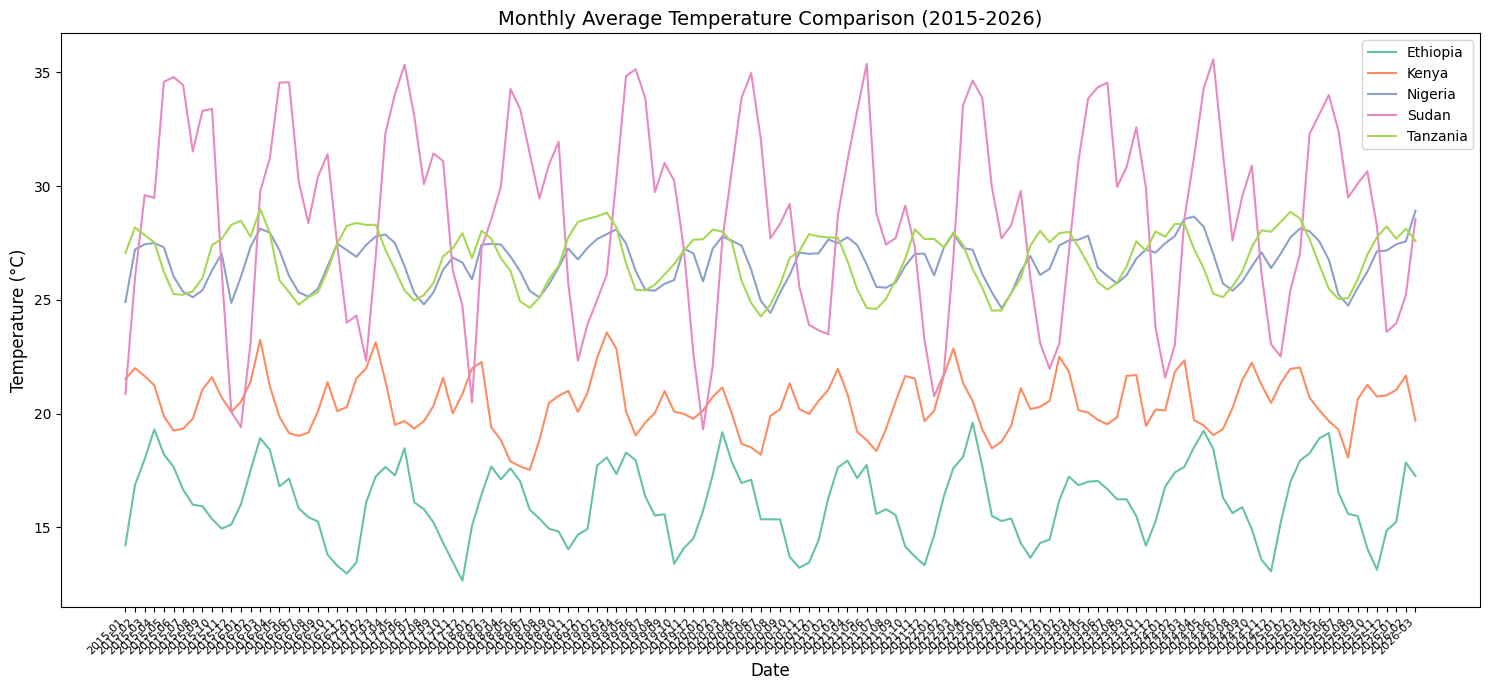


TEMPERATURE STATISTICS BY COUNTRY
           mean  median   std
Country                      
Sudan     28.76   29.16  4.68
Tanzania  26.80   26.99  1.33
Nigeria   26.66   26.82  1.12
Kenya     20.43   20.36  1.44
Ethiopia  16.07   16.04  1.90


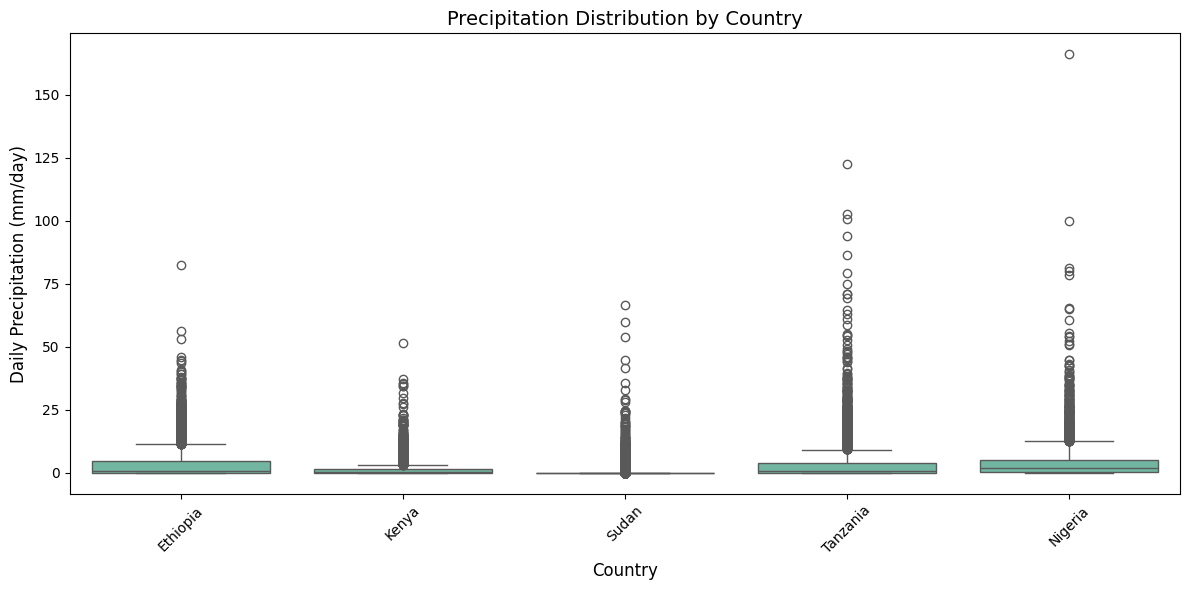


PRECIPITATION STATISTICS BY COUNTRY
          mean  median   std
Country                     
Nigeria   4.21    1.84  7.27
Tanzania  3.74    0.64  8.00
Ethiopia  3.63    0.82  6.29
Kenya     1.47    0.38  3.18
Sudan     0.64    0.00  3.06


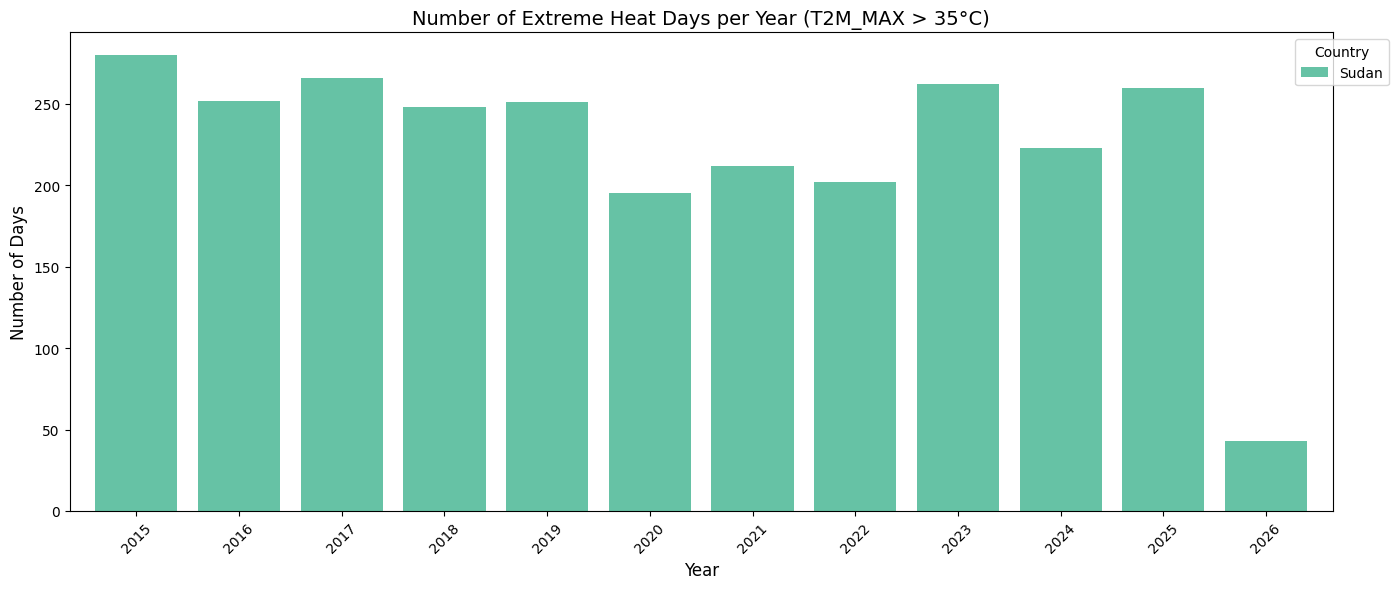

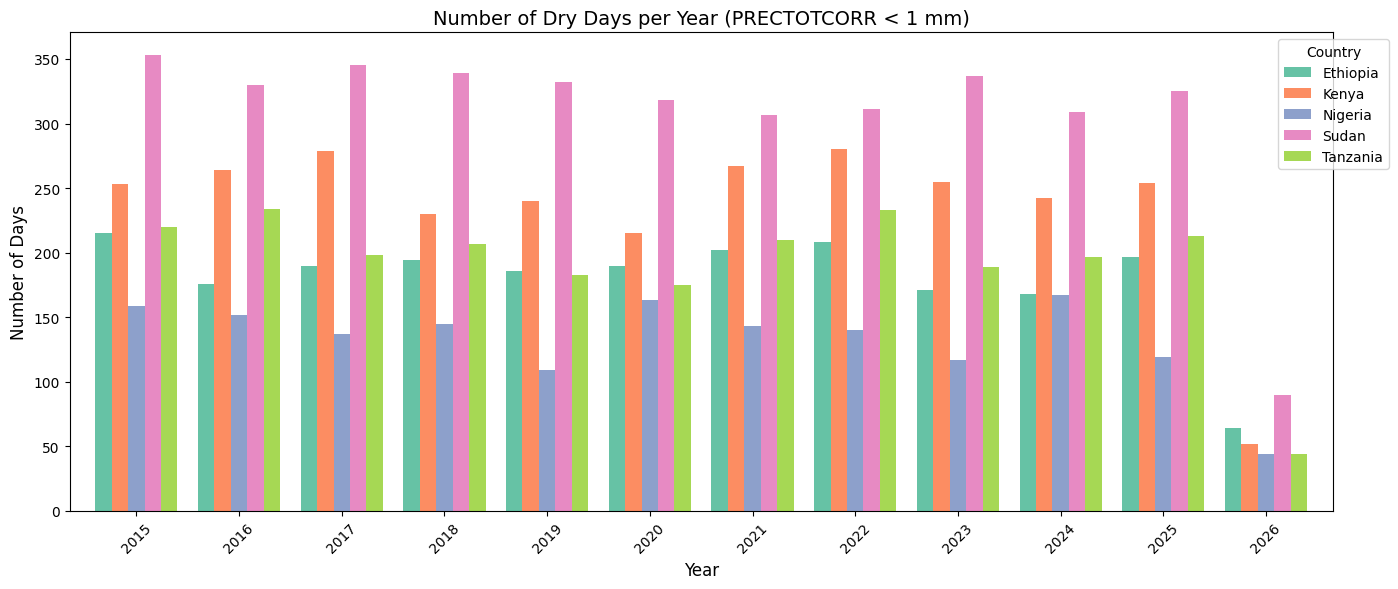


EXTREME EVENTS SUMMARY (2015-2026)
          Total Extreme Heat Days (>35°C)  Average Annual Heat Days  \
Country                                                               
Ethiopia                              NaN                       NaN   
Kenya                                 NaN                       NaN   
Nigeria                               NaN                       NaN   
Sudan                              2694.0                     244.9   
Tanzania                              NaN                       NaN   

          Total Dry Days (<1mm)  Average Annual Dry Days  
Country                                                   
Ethiopia                   2161                    196.5  
Kenya                      2831                    257.4  
Nigeria                    1595                    145.0  
Sudan                      3696                    336.0  
Tanzania                   2303                    209.4  

STATISTICAL TESTING
One-way ANOVA on T2M across 5 co

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, linregress
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")
print("Libraries loaded successfully!")

# ============================================
# STEP 1: LOAD ALL CLEANED CSV FILES
# ============================================

countries = ['ethiopia', 'kenya', 'sudan', 'tanzania', 'nigeria']
df_list = []

for country in countries:
    df = pd.read_csv(f'../data/{country}_clean.csv')
    print(f"✓ Loaded {country}_clean.csv - {len(df)} rows")
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)
print(f"\nTotal combined data: {len(df_all)} rows")
print(f"Countries: {df_all['Country'].unique()}")

# ============================================
# STEP 2: TEMPERATURE TREND COMPARISON
# ============================================

# Create YearMonth column
df_all['Date'] = pd.to_datetime(df_all['Date'])
df_all['YearMonth'] = df_all['Date'].dt.to_period('M')

# Monthly average temperature per country
monthly_temp = df_all.groupby(['YearMonth', 'Country'])['T2M'].mean().unstack()

plt.figure(figsize=(15, 7))
for country in monthly_temp.columns:
    plt.plot(monthly_temp.index.astype(str), monthly_temp[country], linewidth=1.5, label=country)

plt.title('Monthly Average Temperature Comparison (2015-2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# Temperature summary statistics
print("\n" + "="*60)
print("TEMPERATURE STATISTICS BY COUNTRY")
print("="*60)
temp_stats = df_all.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
temp_stats = temp_stats.sort_values('mean', ascending=False)
print(temp_stats)

# ============================================
# STEP 3: PRECIPITATION VARIABILITY COMPARISON
# ============================================

# Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y='PRECTOTCORR', data=df_all)
plt.title('Precipitation Distribution by Country', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Daily Precipitation (mm/day)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Precipitation statistics
print("\n" + "="*60)
print("PRECIPITATION STATISTICS BY COUNTRY")
print("="*60)
precip_stats = df_all.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
precip_stats = precip_stats.sort_values('mean', ascending=False)
print(precip_stats)

# ============================================
# STEP 4: EXTREME EVENT FREQUENCY
# ============================================

# 4a: Extreme heat days (T2M_MAX > 35°C)
df_all['Year'] = df_all['Date'].dt.year
extreme_heat = df_all[df_all['T2M_MAX'] > 35].groupby(['Country', 'Year']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
extreme_heat.T.plot(kind='bar', width=0.8, ax=plt.gca())
plt.title('Number of Extreme Heat Days per Year (T2M_MAX > 35°C)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4b: Dry days (PRECTOTCORR < 1 mm)
dry_days = df_all[df_all['PRECTOTCORR'] < 1].groupby(['Country', 'Year']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
dry_days.T.plot(kind='bar', width=0.8, ax=plt.gca())
plt.title('Number of Dry Days per Year (PRECTOTCORR < 1 mm)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary of extreme events
print("\n" + "="*60)
print("EXTREME EVENTS SUMMARY (2015-2026)")
print("="*60)
extreme_summary = pd.DataFrame({
    'Total Extreme Heat Days (>35°C)': df_all[df_all['T2M_MAX'] > 35].groupby('Country').size(),
    'Average Annual Heat Days': df_all[df_all['T2M_MAX'] > 35].groupby('Country').size() / 11,
    'Total Dry Days (<1mm)': df_all[df_all['PRECTOTCORR'] < 1].groupby('Country').size(),
    'Average Annual Dry Days': df_all[df_all['PRECTOTCORR'] < 1].groupby('Country').size() / 11
})
print(extreme_summary.round(1))

# ============================================
# STEP 5: STATISTICAL TESTING (ANOVA)
# ============================================

print("\n" + "="*60)
print("STATISTICAL TESTING")
print("="*60)

# Prepare data for ANOVA
groups = [group['T2M'].dropna().values for name, group in df_all.groupby('Country')]
anova_result = f_oneway(*groups)
print(f"One-way ANOVA on T2M across 5 countries:")
print(f"F-statistic: {anova_result.statistic:.4f}")
print(f"P-value: {anova_result.pvalue:.4e}")

if anova_result.pvalue < 0.05:
    print("✓ Result: P-value < 0.05 - Significant temperature differences between countries")
else:
    print("✗ Result: P-value > 0.05 - No significant temperature differences")

# ============================================
# STEP 6: VULNERABILITY RANKING
# ============================================

print("\n" + "="*60)
print("CLIMATE VULNERABILITY RANKING")
print("="*60)

# Calculate ranking scores
ranking_data = []

for country in df_all['Country'].unique():
    country_data = df_all[df_all['Country'] == country]
    
    # Temperature score (higher mean = higher vulnerability)
    temp_score = country_data['T2M'].mean()
    
    # Extreme heat score
    heat_score = len(country_data[country_data['T2M_MAX'] > 35]) / len(country_data) * 100
    
    # Dry days score
    dry_score = len(country_data[country_data['PRECTOTCORR'] < 1]) / len(country_data) * 100
    
    # Precipitation variability (higher std = more unstable)
    precip_std = country_data['PRECTOTCORR'].std()
    
    ranking_data.append({
        'Country': country,
        'Mean Temp (°C)': round(temp_score, 1),
        'Heat Days (%)': round(heat_score, 1),
        'Dry Days (%)': round(dry_score, 1),
        'Precip Variability (mm)': round(precip_std, 1)
    })

ranking_df = pd.DataFrame(ranking_data)

# Calculate composite vulnerability score
for col in ['Mean Temp (°C)', 'Heat Days (%)', 'Dry Days (%)', 'Precip Variability (mm)']:
    min_val = ranking_df[col].min()
    max_val = ranking_df[col].max()
    if max_val != min_val:
        ranking_df[f'{col}_norm'] = (ranking_df[col] - min_val) / (max_val - min_val)
    else:
        ranking_df[f'{col}_norm'] = 0

ranking_df['Vulnerability Score'] = ranking_df[[f'{col}_norm' for col in ['Mean Temp (°C)', 'Heat Days (%)', 'Dry Days (%)', 'Precip Variability (mm)']]].mean(axis=1)
ranking_df = ranking_df.sort_values('Vulnerability Score', ascending=False)

print("\nVULNERABILITY RANKING (Highest to Lowest Risk):")
print("="*60)
for i, row in ranking_df.iterrows():
    print(f"{i+1}. {row['Country']} - Score: {row['Vulnerability Score']:.3f}")
    print(f"   • Mean Temp: {row['Mean Temp (°C)']}°C")
    print(f"   • Extreme Heat Days: {row['Heat Days (%)']}% of year")
    print(f"   • Dry Days: {row['Dry Days (%)']}% of year")
    print()

# ============================================
# STEP 7: 5 COP32 BULLET POINTS
# ============================================

print("\n" + "="*60)
print("KEY FINDINGS FOR COP32 - EVIDENCE-BACKED INSIGHTS")
print("="*60)

# Calculate temperature trend per country
print("\n📊 TREND ANALYSIS (2015-2026):")

trend_results = []
for country in df_all['Country'].unique():
    country_data = df_all[df_all['Country'] == country]
    yearly_temp = country_data.groupby('Year')['T2M'].mean()
    if len(yearly_temp) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(yearly_temp.index, yearly_temp.values)
        trend_results.append({'Country': country, 'Trend_°C_per_year': slope, 'R_squared': r_value**2})

trend_df = pd.DataFrame(trend_results).sort_values('Trend_°C_per_year', ascending=False)
fastest_warming = trend_df.iloc[0]['Country']
fastest_trend = trend_df.iloc[0]['Trend_°C_per_year']

# Most unstable precipitation
most_unstable = ranking_df.iloc[0]['Country']

# Most heat stress
most_heat = ranking_df.iloc[0]['Country']

# Ethiopia comparison
ethiopia_row = ranking_df[ranking_df['Country'] == 'Ethiopia']
if len(ethiopia_row) > 0:
    ethiopia_temp = ethiopia_row['Mean Temp (°C)'].values[0]
    ethiopia_rank = ranking_df[ranking_df['Country'] == 'Ethiopia'].index[0] + 1
else:
    ethiopia_temp = 0
    ethiopia_rank = 0

regional_avg_temp = ranking_df['Mean Temp (°C)'].mean()

# Champion for finance
champion = ranking_df.iloc[0]['Country']

print(f"\n1. FASTEST WARMING: {fastest_warming} is warming at {fastest_trend:.4f}°C per year")
print(f"   → This suggests accelerating temperature increases requiring urgent adaptation measures")

print(f"\n2. MOST UNSTABLE PRECIPITATION: {most_unstable} shows the highest precipitation variability")
print(f"   → Unpredictable rainfall patterns threaten agriculture and water security")

print(f"\n3. EXTREME HEAT & DROUGHT STRESS: {most_heat} experiences the highest percentage of extreme heat days")
print(f"   → Combined with high dry day frequency, this indicates severe climate stress on communities")

print(f"\n4. ETHIOPIA'S PROFILE: Ethiopia ranks #{ethiopia_rank} in vulnerability with mean temp {ethiopia_temp}°C vs regional avg {regional_avg_temp:.1f}°C")
print(f"   → Ethiopia is comparatively less vulnerable than regional neighbors, positioning it as a climate leader")

print(f"\n5. PRIORITY FOR CLIMATE FINANCE: {champion} should champion for priority adaptation finance")
print(f"   → The data supports urgent investment in early warning systems and drought-resistant infrastructure")

print("\n" + "="*60)
print("RECOMMENDATIONS FOR COP32 POSITION PAPER:")
print("="*60)
print("• Based on the evidence, Ethiopia should advocate for:")
print("  1. Increased adaptation finance for the most vulnerable countries (Sudan, Nigeria)")
print("  2. Regional early warning systems for extreme heat and drought events")
print("  3. Investment in climate-resilient agriculture and water infrastructure")
print("  4. Loss and damage compensation for countries with highest vulnerability scores")
print("  5. Technology transfer for drought monitoring and prediction systems")

